In [3]:
# Import required libraries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from pathlib import Path
from skimage import io
from skimage.io import imread_collection
import datetime
import re
import builtins
import os
import imageio.v2 as imageio
from IPython.display import Image, display
from collections import defaultdict
import pandas as pd

In [4]:
# INPUT experiment name
experiment_name = "VTF---2026-07-11---X-87"
log_file_name = "log_1007_1402_OB1.csv"

# Path specification

base_path = Path("/mnt/large_storage/shared_storage/data/Vicen")
data_path = base_path / "data" / experiment_name
log_file = base_path / "microfluidic_logs" / log_file_name

#data_path = Path("/mnt/large_storage/shared_storage/data/Vicen/data/")

output_path = base_path / "GIFs" / experiment_name
output_path.mkdir(parents=True, exist_ok=True)

if not data_path.exists():
    raise FileNotFoundError(f"data_path does not exist: {data_path}")

print(f"  data_path        = {data_path}")
print(f"  experiment_name  = {experiment_name}")
print(f"  log_file_name    = {log_file_name}")
print(f"  output_path      = {output_path}")

  data_path        = /mnt/large_storage/shared_storage/data/Vicen/data/VTF---2026-07-11---X-87
  experiment_name  = VTF---2026-07-11---X-87
  log_file_name    = log_1007_1402_OB1.csv
  output_path      = /mnt/large_storage/shared_storage/data/Vicen/GIFs/VTF---2026-07-11---X-87


In [5]:
# Load the CSV file with error handling
try:
    log_df = pd.read_csv(log_file)
except Exception as e:
    raise RuntimeError(f"Failed to read CSV '{log_file}': {e}")

# Parse the log file name to extract the start time
# Format: log_DDMM_HHMM (DD = day, MM = month)
match = re.search(r'log_(\d{4})_(\d{4})', log_file_name)
if not match:
    raise ValueError(f"log_file_name does not match expected pattern: {log_file_name}")
day_month = match.group(1)
# split day_month into day and month
day = day_month[:2]
month = day_month[2:]
hour_minute = match.group(2)

# Create a datetime object for the start time (using extracted day and month)
start_time = datetime.datetime.strptime(f"2026-{month}-{day} {hour_minute[:2]}:{hour_minute[2:]}", "%Y-%m-%d %H:%M")

# Detect the time column (tolerant to small name variations)
time_col = None
for c in log_df.columns:
    if c.strip().lower().startswith('time'):
        time_col = c
        break
if time_col is None:
    raise KeyError(f"No time column found in CSV. Available columns: {list(log_df.columns)}")

# Ensure numeric time values
log_df[time_col] = pd.to_numeric(log_df[time_col], errors='coerce')
if log_df[time_col].isna().any():
    raise ValueError(f"Non-numeric values found in time column '{time_col}'")

# Add the absolute_time column by adding the time (s) column to the start time
log_df['absolute_time'] = log_df[time_col].apply(lambda t: start_time + datetime.timedelta(seconds=float(t)))

# Diagnostic messages
print(f"✓ Loaded CSV file from: {log_file}")
print(f"  Detected time column: {time_col}")
print(f"  Parsed start_time: {start_time}")
print(f"  Time start: {log_df['absolute_time'].iloc[0]}")
print(f"  Time finish: {log_df['absolute_time'].iloc[-1]}")
print(f"  Total time: {log_df[time_col].iloc[-1]:.2f} seconds")
print(f"  Number of data points: {len(log_df)}")

✓ Loaded CSV file from: /mnt/large_storage/shared_storage/data/Vicen/microfluidic_logs/log_1007_1402_OB1.csv
  Detected time column: Time (s)
  Parsed start_time: 2026-07-10 14:02:00
  Time start: 2026-07-10 14:02:00.000850
  Time finish: 2026-07-11 23:27:58.000859
  Total time: 120358.00 seconds
  Number of data points: 120359


In [6]:
# Overview of log_df
print("Shape:", log_df.shape)
display(log_df.head())
display(log_df.info())
display(log_df.describe(include='all'))

Shape: (120359, 20)


,Time (s),CH 1 Pressure (mbar),CH 1 Flow (ul/min),CH 1 Medium left (ml),CH 1 Mode,CH 1 Reference flow (ul/min),CH 1 Constant pressure (mbar),CH 1 P gain,CH 1 I gain,CH 1 D gain,CH 2 Pressure (mbar),CH 2 Flow (ul/min),CH 2 Medium left (ml),CH 2 Mode,CH 2 Reference flow (ul/min),CH 2 Constant pressure (mbar),CH 2 P gain,CH 2 I gain,CH 2 D gain,absolute_time
0,0.000850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.334698,-0.107407,50.000000,0,42.0,NaN,0.05,0.1,0.05,2026-07-10 14:02:00.000850
1,1.000281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.334698,-0.511111,50.000009,0,42.0,NaN,0.05,0.1,0.05,2026-07-10 14:02:01.000281
2,2.001029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.634328,-0.518519,50.000017,0,42.0,NaN,0.05,0.1,0.05,2026-07-10 14:02:02.001029
3,3.000751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.938919,-0.537037,50.000026,0,42.0,NaN,0.05,0.1,0.05,2026-07-10 14:02:03.000751
4,4.001111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.403436,-0.570370,50.000036,0,42.0,NaN,0.05,0.1,0.05,2026-07-10 14:02:04.001111


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120359 entries, 0 to 120358
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Time (s)                       120359 non-null  float64       
 1   CH 1 Pressure (mbar)           0 non-null       float64       
 2   CH 1 Flow (ul/min)             0 non-null       float64       
 3   CH 1 Medium left (ml)          0 non-null       float64       
 4   CH 1 Mode                      0 non-null       float64       
 5   CH 1 Reference flow (ul/min)   0 non-null       float64       
 6   CH 1 Constant pressure (mbar)  0 non-null       float64       
 7   CH 1 P gain                    0 non-null       float64       
 8   CH 1 I gain                    0 non-null       float64       
 9   CH 1 D gain                    0 non-null       float64       
 10  CH 2 Pressure (mbar)           120359 non-null  float64       
 11  

None

,Time (s),CH 1 Pressure (mbar),CH 1 Flow (ul/min),CH 1 Medium left (ml),CH 1 Mode,CH 1 Reference flow (ul/min),CH 1 Constant pressure (mbar),CH 1 P gain,CH 1 I gain,CH 1 D gain,CH 2 Pressure (mbar),CH 2 Flow (ul/min),CH 2 Medium left (ml),CH 2 Mode,CH 2 Reference flow (ul/min),CH 2 Constant pressure (mbar),CH 2 P gain,CH 2 I gain,CH 2 D gain,absolute_time
count,120359.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120359.000000,120359.000000,120359.000000,120359.000000,112907.000000,7452.000000,1.203590e+05,1.203590e+05,1.203590e+05,120359
mean,60179.001085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.247031,16.834979,31.360341,0.061915,15.003109,160.258991,5.000000e-02,1.000000e-01,5.000000e-02,2026-07-11 06:44:59.001084672
min,0.000850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.334698,-120.000000,16.229311,0.000000,15.000000,0.000000,5.000000e-02,1.000000e-01,5.000000e-02,2026-07-10 14:02:00.000850
25%,30089.500500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.578628,14.966667,23.751681,0.000000,15.000000,50.000000,5.000000e-02,1.000000e-01,5.000000e-02,2026-07-10 22:23:29.500499968
50%,60179.001138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.586845,15.003704,31.276320,0.000000,15.000000,250.000000,5.000000e-02,1.000000e-01,5.000000e-02,2026-07-11 06:44:59.001137920
75%,90268.500624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.051166,15.088889,38.796318,0.000000,15.000000,250.000000,5.000000e-02,1.000000e-01,5.000000e-02,2026-07-11 15:06:28.500624384
max,120358.000859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1512.266423,120.000000,50.000155,1.000000,42.000000,1500.000000,5.000000e-02,1.000000e-01,5.000000e-02,2026-07-11 23:27:58.000859
std,34744.794804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.914915,11.468048,8.840410,0.241002,0.289702,160.353003,1.387785e-17,2.775569e-17,1.387785e-17,NaN


/home/hslab/miniconda3/envs/delta_evomachine/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/hslab/miniconda3/envs/delta_evomachine/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


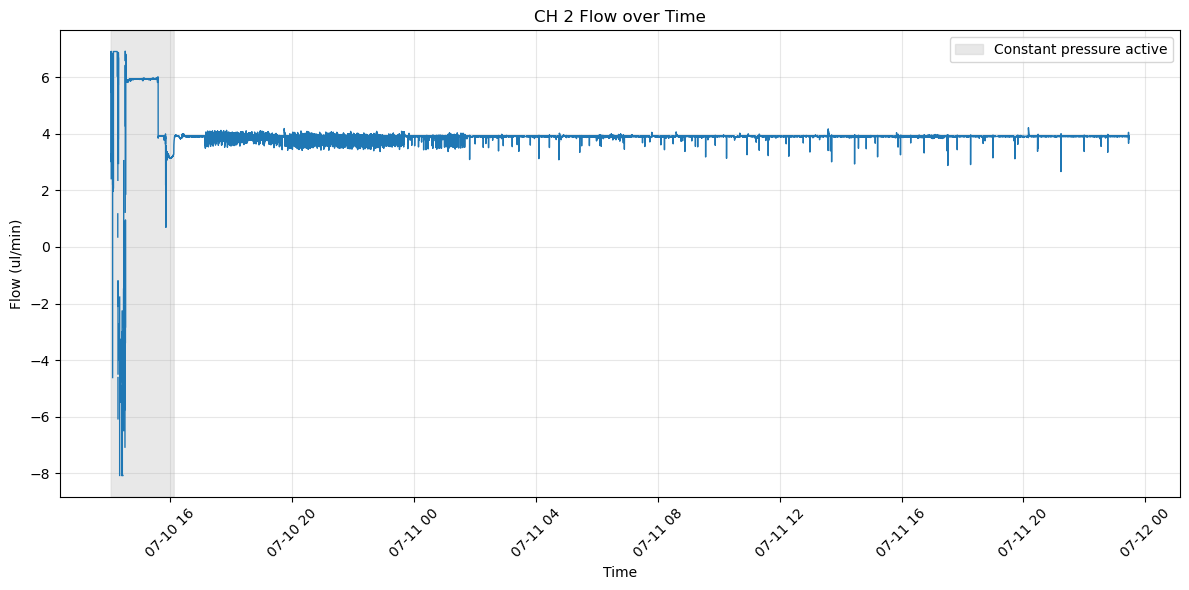

In [7]:
# Plot the flow data over time
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Shade regions where either constant-pressure channel is active (not NaN)
mask = (log_df['CH 1 Constant pressure (mbar)'].notna() |
        log_df['CH 2 Constant pressure (mbar)'].notna())
ax.fill_between(log_df['absolute_time'], 0, 1,
                where=mask,
                transform=ax.get_xaxis_transform(),
                color='lightgray', alpha=0.5,
                label='Constant pressure active')

ax.plot(log_df['absolute_time'], np.log2(log_df['CH 2 Flow (ul/min)']), linewidth=1)
ax.set_xlabel('Time')
ax.set_ylabel('Flow (ul/min)')
ax.set_title('CH 2 Flow over Time')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

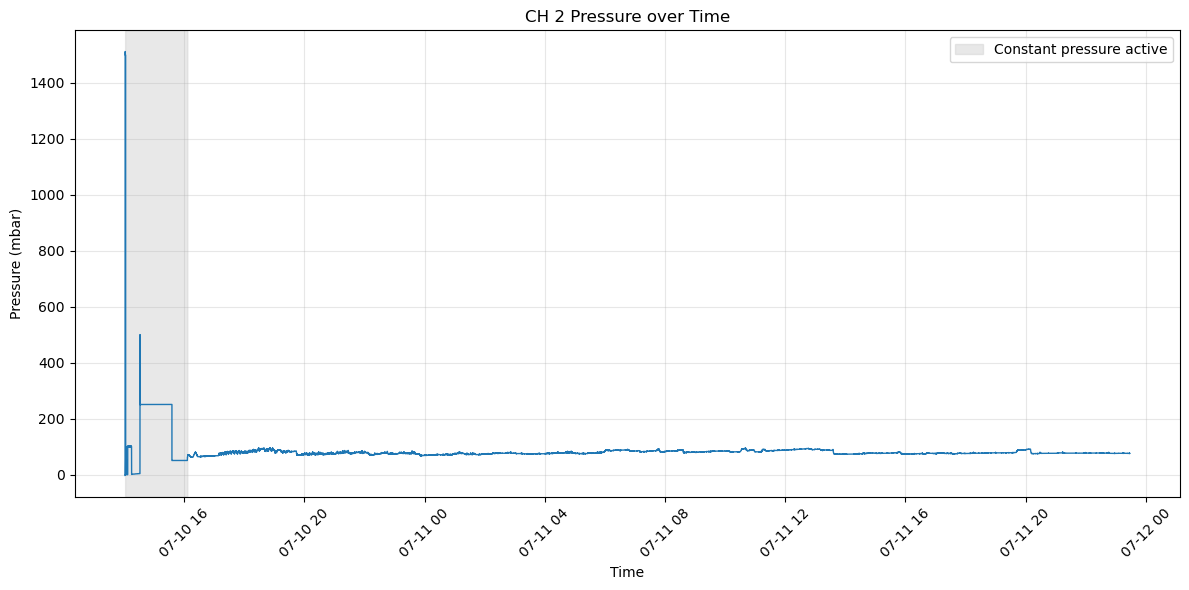

In [8]:
# Plot the CH 2 pressure data over time
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Shade regions where either constant-pressure channel is active (not NaN)
mask = (log_df['CH 1 Constant pressure (mbar)'].notna() |
    log_df['CH 2 Constant pressure (mbar)'].notna())
ax.fill_between(log_df['absolute_time'], 0, 1,
        where=mask,
        transform=ax.get_xaxis_transform(),
        color='lightgray', alpha=0.5,
        label='Constant pressure active')

ax.plot(log_df['absolute_time'], log_df['CH 2 Pressure (mbar)'], linewidth=1)
ax.set_xlabel('Time')
ax.set_ylabel('Pressure (mbar)')
ax.set_title('CH 2 Pressure over Time')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()